In [1]:
import seaborn as sns

In [2]:
df=sns.load_dataset('iris')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [3]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [4]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

<Axes: >

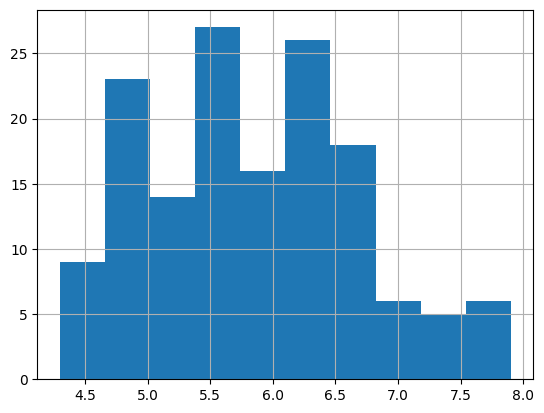

In [7]:
df['sepal_length'].hist()

<Axes: >

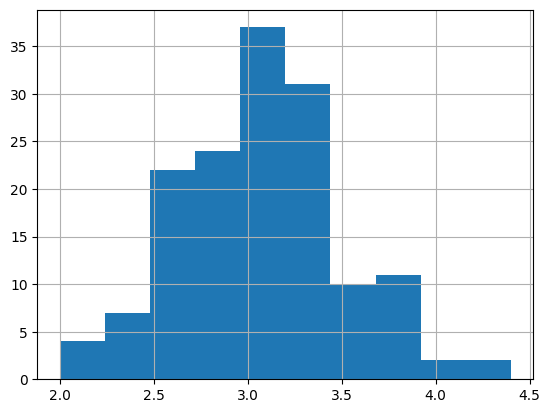

In [9]:
df['sepal_width'].hist()
# df['petal_length'].hist()
# df['petal_width'].hist()

array([[<Axes: title={'center': 'sepal_length'}>,
        <Axes: title={'center': 'sepal_width'}>],
       [<Axes: title={'center': 'petal_length'}>,
        <Axes: title={'center': 'petal_width'}>]], dtype=object)

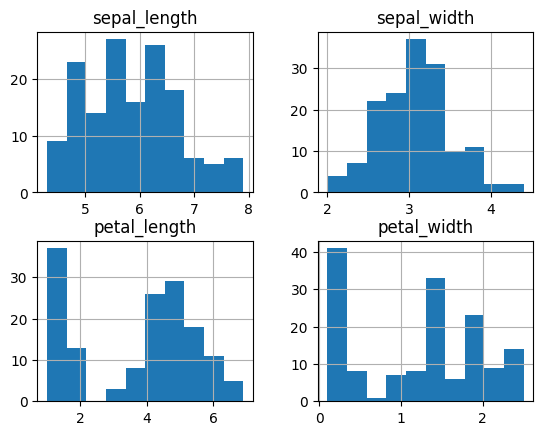

In [10]:
df.hist()

<Axes: >

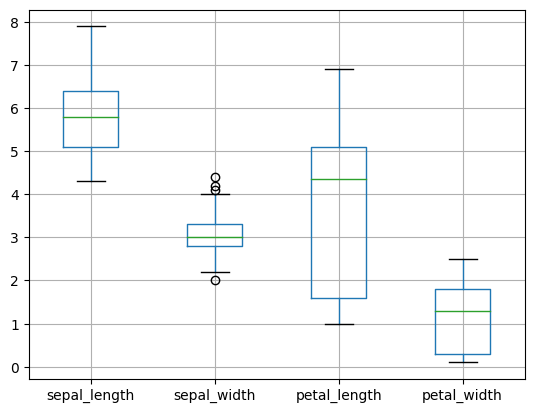

In [11]:
df.boxplot()

<Axes: xlabel='sepal_width'>

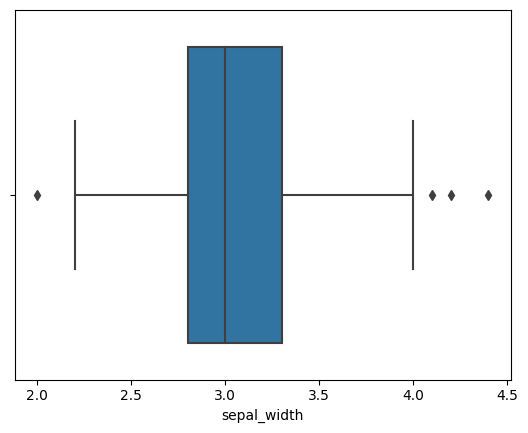

In [12]:
import seaborn as sns
sns.boxplot(x=df['sepal_width'],data=df)

In [20]:
import numpy as np

outliers = []
thres = 2.3
data = df['sepal_width']
mean = np.mean(data)
std = np.std(data)
print('mean - ',mean)
print('std - ',std)
for i in data:
    z_score = (i - mean)/std
    if(np.abs(z_score) > thres):
        outliers.append(i)
print('outliers by z score - ',outliers)

mean -  3.0573333333333337
std -  0.4344109677354946
outliers by z score -  [4.4, 4.1, 4.2, 2.0]


In [17]:
outliers = []
def detect_outliers_iqr(data):
    data = sorted(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    print('q1 - ',q1,'q3 - ', q3)
    IQR = q3-q1
    lwr_bound = q1-(1.5*IQR)
    upr_bound = q3+(1.5*IQR)
    print('lwr bound - ',lwr_bound,'upr bound - ', upr_bound)
    for i in data: 
        if (i<lwr_bound or i>upr_bound):
            outliers.append(i)
    return outliers
marks_outliers = detect_outliers_iqr(df['sepal_width'])
print("Outliers from IQR method: ", marks_outliers)

q1 -  2.8 q3 -  3.3
lwr bound -  2.05 upr bound -  4.05
Outliers from IQR method:  [2.0, 4.1, 4.2, 4.4]
